# Tech Challenge FIAP — Olist

## Impacto do atraso na entrega sobre o faturamento

### Pergunta principal

Como o atraso na entrega pode afetar a satisfação do cliente e o faturamento futuro da companhia?

### Objetivo

Analisar os pedidos da Olist para entender:

- quantos pedidos atrasaram;
- se o atraso está relacionado a avaliações menores;
- qual o valor financeiro associado a pedidos atrasados e mal avaliados;
- quais regiões e categorias merecem atenção;
- quais ações podem melhorar a operação.

### Observação importante

Cada tabela possui um nível diferente de informação.

Por exemplo:

- um pedido pode ter vários pagamentos;
- um pedido pode ter vários itens;
- um pedido pode possuir mais de uma avaliação.

Por isso, primeiro vamos organizar os dados para evitar que o mesmo pedido seja contado mais de uma vez.



In [71]:
# Importação das bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

#Usaremos:

# - `pandas` para trabalhar com tabelas;
# - `numpy` para cálculos;
# - `matplotlib` e `seaborn` para gráficos.

In [72]:
# 1. Carregando todas as tabelas necessárias de uma vez
orders = pd.read_csv('database/olist_orders_dataset.csv')
payments = pd.read_csv('database/olist_order_payments_dataset.csv')
reviews = pd.read_csv('database/olist_order_reviews_dataset.csv')
customers = pd.read_csv('database/olist_customers_dataset.csv')
items = pd.read_csv('database/olist_order_items_dataset.csv')
products = pd.read_csv('database/olist_products_dataset.csv')
sellers = pd.read_csv('database/olist_sellers_dataset.csv')
category_translation = pd.read_csv('database/product_category_name_translation.csv')

# POR QUE: carregar tudo no início (e não em blocos separados ao longo do
# notebook, como no original) facilita auditoria e evita reprocessamento
# de merges intermediários (df_projeto, df_extra, df_final) que existiam antes.

# print("Pedidos:", orders.shape)
# print("Pagamentos:", payments.shape)
# print("Avaliações:", reviews.shape)
# print("Clientes:", customers.shape)
# print("Itens:", items.shape)
# print("Produtos:", products.shape)
# print("Vendedores:", sellers.shape)
# print("Tradução de categorias:", category_translation.shape)

## Como os dados estão organizados

A tabela `orders` possui uma linha por pedido.

Já as tabelas `payments` e `order_items` podem possuir várias linhas para o mesmo pedido.

Exemplo:

- um pedido pode ser pago com cartão e voucher;
- um pedido pode conter vários produtos;
- um pedido pode ter mais de uma avaliação.

Se juntarmos tudo diretamente, o mesmo pedido poderá aparecer várias vezes. Isso faria a receita e outros indicadores ficarem maiores do que realmente são.

In [73]:
## 2. Conversão de colunas de data para o tipo datetime

colunas_data = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

# Convertemos as colunas de data para o tipo datetime, para facilitar a análise temporal.
for coluna in colunas_data:
    orders[coluna] = pd.to_datetime(orders[coluna])

# Convertemos a coluna de data de criação das avaliações para o tipo datetime.
reviews['review_creation_date'] = pd.to_datetime(
    reviews['review_creation_date']
)

# Análise de granularidade dos pedidos
total_pedidos = len(orders)

# Filtramos apenas os pedidos que foram entregues, ou seja, aqueles que possuem uma data de entrega ao cliente.
orders_entregues = orders[
    orders['order_delivered_customer_date'].notna()
].copy()

# print(f'Total de pedidos: {total_pedidos:,}') 99,441
# print(f'Pedidos entregues analisados: {len(orders_entregues):,}') 96,476
# print(f'Pedidos não utilizados: {total_pedidos - len(orders_entregues):,}')  2,965

Para calcular o atraso, precisamos conhecer a data real da entrega.

Por isso, os pedidos sem data de entrega não entram na análise principal.

Essa é uma limitação do estudo, pois pedidos cancelados ou não entregues não serão avaliados nesta etapa.

In [74]:
orders_entregues['dias_atraso'] = (
    orders_entregues['order_delivered_customer_date'] -
    orders_entregues['order_estimated_delivery_date']
).dt.days

orders_entregues['foi_atraso'] = (
    orders_entregues['dias_atraso'] > 0
)

orders_entregues[
    ['order_id', 'dias_atraso', 'foi_atraso']
].head()

,order_id,dias_atraso,foi_atraso
0,e481f51cbdc54678b7cc49136f2d6af7,-8,False
1,53cdb2fc8bc7dce0b6741e2150273451,-6,False
2,47770eb9100c2d0c44946d9cf07ec65d,-18,False
3,949d5b44dbf5de918fe9c16f97b45f8a,-13,False
4,ad21c59c0840e6cb83a9ceb5573f8159,-10,False


A coluna `dias_atraso` funciona assim:

- valor positivo: o pedido chegou atrasado;
- valor zero: chegou exatamente no prazo;
- valor negativo: chegou antes do prazo.

Consideramos um pedido atrasado quando `dias_atraso` é maior que zero.

In [75]:
payments_pedido = (
    payments
    .groupby('order_id', as_index=False)
    .agg(
        payment_value=('payment_value', 'sum'),
        quantidade_pagamentos=('payment_value', 'count')
    )
)

payments_pedido.head()

,order_id,payment_value,quantidade_pagamentos
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,1
1,00018f77f2f0320c557190d7a144bdd3,259.83,1
2,000229ec398224ef6ca0657da4fc703e,216.87,1
3,00024acbcdf0a6daa1e931b038114c75,25.78,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,1


Um pedido pode ter mais de um pagamento.

Por isso, somamos todos os pagamentos antes de juntar essa informação aos pedidos.

Assim, `payment_value` representa o valor total pago em cada pedido.

In [76]:
reviews_pedido = (
    reviews
    .sort_values('review_creation_date')
    .drop_duplicates('order_id', keep='last')
    [['order_id', 'review_score']]
)

reviews_pedido.head()

,order_id,review_score
70906,809a282bbd5dbcabb6f2f724fca862ec,1
37547,bfbd0f9bdef84302105ad712db648a6c,1
5503,e5215415bb6f76fe3b7cb68103a0d1c0,1
60439,e2144124f98f3bf46939bc5183104041,4
41042,9aa3197e4887919fde0307fc23601d7a,4


Para evitar repetição, mantemos uma avaliação por pedido.

Quando existem várias avaliações, usamos a avaliação mais recente.

In [77]:
df_pedidos = (
    orders_entregues
    .merge(payments_pedido, on='order_id', how='left')
    .merge(reviews_pedido, on='order_id', how='left')
    .merge(
        customers[
            [
                'customer_id',
                'customer_unique_id',
                'customer_state'
            ]
        ],
        on='customer_id',
        how='left'
    )
)

print('Linhas da base:', len(df_pedidos))
print('Pedidos únicos:', df_pedidos['order_id'].nunique())

Linhas da base: 96476
Pedidos únicos: 96476


In [78]:
duplicados = df_pedidos['order_id'].duplicated().sum()

print(f'Pedidos repetidos: {duplicados}')

if duplicados == 0:
    print('A base está correta: existe uma linha por pedido.')
else:
    print('Atenção: ainda existem pedidos repetidos.')

Pedidos repetidos: 0
A base está correta: existe uma linha por pedido.


Esta é a principal verificação do notebook.

Como a análise financeira será feita no nível do pedido, cada `order_id` deve aparecer apenas uma vez.

Essa correção evita somar o valor do mesmo pedido várias vezes.

# Análise dos resultados


In [79]:
total_analisado = df_pedidos['order_id'].nunique()
pedidos_atrasados = df_pedidos['foi_atraso'].sum()
percentual_atraso = pedidos_atrasados / total_analisado * 100

print(f'Pedidos analisados: {total_analisado:,}')
print(f'Pedidos atrasados: {pedidos_atrasados:,}')
print(f'Percentual de atraso: {percentual_atraso:.2f}%')

Pedidos analisados: 96,476
Pedidos atrasados: 6,535
Percentual de atraso: 6.77%


In [80]:
estatisticas_atraso = df_pedidos['dias_atraso'].describe()

print(estatisticas_atraso)

count    96476.000000
mean       -11.876881
std         10.183854
min       -147.000000
25%        -17.000000
50%        -12.000000
75%         -7.000000
max        188.000000
Name: dias_atraso, dtype: float64


A média mostra o atraso médio, mas pode ser influenciada por casos muito extremos.

Por isso, também observaremos:

- mediana: atraso típico;
- desvio-padrão: variação dos atrasos;
- mínimo e máximo: amplitude dos dados;
- quartis: distribuição dos pedidos.

In [81]:
dias = df_pedidos['dias_atraso'].dropna()

media_atraso = dias.mean()
mediana_atraso = dias.median()
desvio_padrao = dias.std()
amplitude = dias.max() - dias.min()

q1 = dias.quantile(0.25)
q3 = dias.quantile(0.75)
iqr = q3 - q1

print(f'Média de dias em relação ao prazo: {media_atraso:.2f}')
print(f'Mediana de dias em relação ao prazo: {mediana_atraso:.2f}')
print(f'Desvio-padrão: {desvio_padrao:.2f}')
print(f'Amplitude: {amplitude:.2f}')
print(f'IQR: {iqr:.2f}')

Média de dias em relação ao prazo: -11.88
Mediana de dias em relação ao prazo: -12.00
Desvio-padrão: 10.18
Amplitude: 335.00
IQR: 10.00


A mediana será usada como principal referência porque os prazos de entrega podem possuir valores extremos.

O IQR representa a distância entre o primeiro e o terceiro quartil. Ele ajuda a identificar a faixa onde está a maior parte dos pedidos.

In [82]:
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

outliers = df_pedidos[
    (df_pedidos['dias_atraso'] < limite_inferior) |
    (df_pedidos['dias_atraso'] > limite_superior)
]

print(f'Limite inferior: {limite_inferior:.2f}')
print(f'Limite superior: {limite_superior:.2f}')
print(f'Quantidade de possíveis outliers: {len(outliers):,}')

Limite inferior: -32.00
Limite superior: 8.00
Quantidade de possíveis outliers: 4,301


Os outliers não serão removidos automaticamente.

Um atraso muito alto pode representar:

- erro de registro;
- situação excepcional;
- problema logístico real;
- pedido com comportamento diferente do padrão.

Neste projeto, os outliers serão mantidos, mas destacados para investigação.

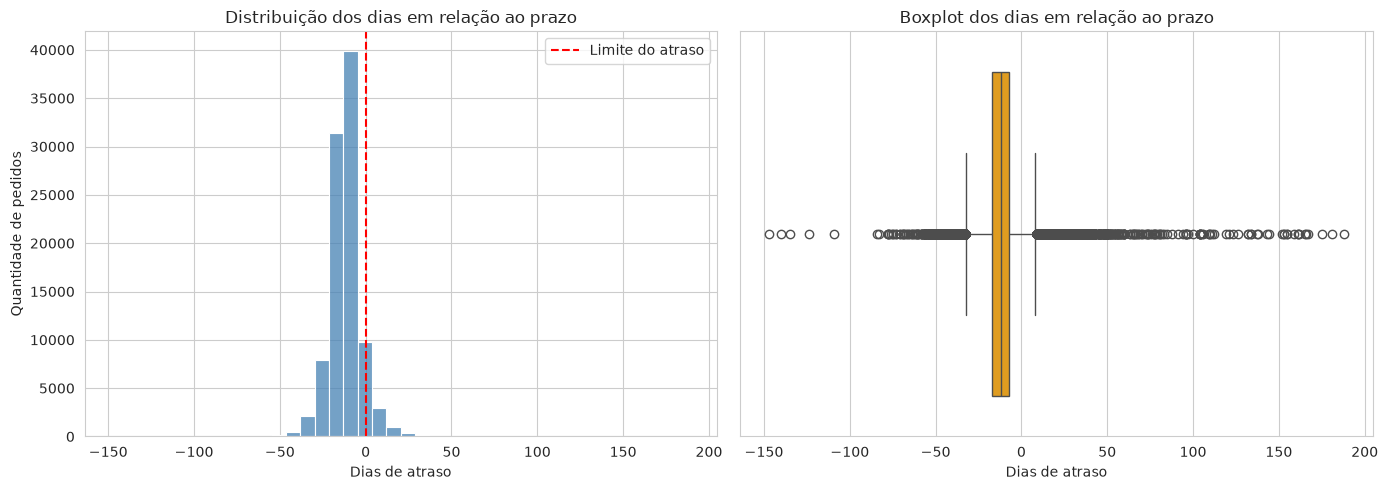

In [83]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=df_pedidos,
    x='dias_atraso',
    bins=40,
    color='steelblue',
    ax=axes[0]
)

axes[0].axvline(
    0,
    color='red',
    linestyle='--',
    label='Limite do atraso'
)

axes[0].set_title('Distribuição dos dias em relação ao prazo')
axes[0].set_xlabel('Dias de atraso')
axes[0].set_ylabel('Quantidade de pedidos')
axes[0].legend()

sns.boxplot(
    data=df_pedidos,
    x='dias_atraso',
    color='orange',
    ax=axes[1]
)

axes[1].set_title('Boxplot dos dias em relação ao prazo')
axes[1].set_xlabel('Dias de atraso')

plt.tight_layout()
plt.show()

In [84]:
satisfacao = (
    df_pedidos
    .dropna(subset=['review_score'])
    .groupby('foi_atraso')
    .agg(
        nota_media=('review_score', 'mean'),
        nota_mediana=('review_score', 'median'),
        pedidos=('order_id', 'nunique'),
        percentual_notas_baixas=(
            'review_score',
            lambda notas: (notas <= 2).mean() * 100
        )
    )
    .reset_index()
)

satisfacao['situacao'] = satisfacao['foi_atraso'].map({
    False: 'No prazo',
    True: 'Com atraso'
})

satisfacao

,foi_atraso,nota_media,nota_mediana,pedidos,percentual_notas_baixas,situacao
0,False,4.290135,5.0,89448,9.272426,No prazo
1,True,2.270918,1.0,6382,62.394234,Com atraso


A comparação entre os grupos permite verificar se os pedidos atrasados apresentam avaliações menores.

A média é apresentada, mas também usamos a mediana e o percentual de notas baixas para evitar uma conclusão baseada em apenas um indicador.

/tmp/ipykernel_51223/2168843753.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


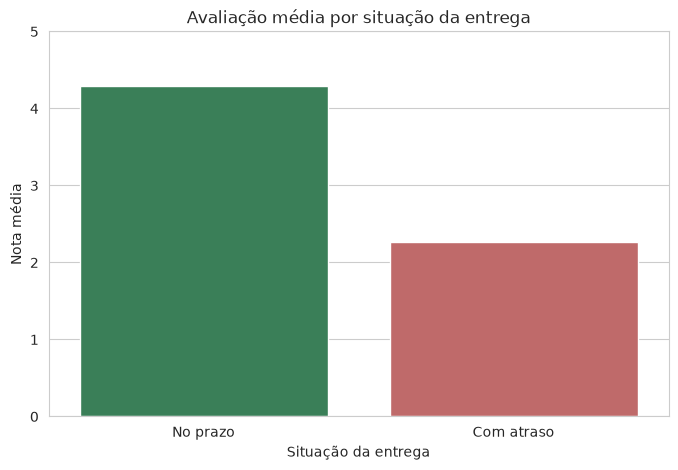

In [85]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=satisfacao,
    x='situacao',
    y='nota_media',
    palette={
        'No prazo': 'seagreen',
        'Com atraso': 'indianred'
    }
)

plt.title('Avaliação média por situação da entrega')
plt.xlabel('Situação da entrega')
plt.ylabel('Nota média')
plt.ylim(0, 5)

plt.show()

# Receita em risco




Para este projeto, definimos como receita em risco o valor de pedidos que:

1. foram entregues com atraso; e
2. receberam nota igual ou menor que 2.

Essa definição não representa perda financeira comprovada. Ela representa um valor associado a uma experiência negativa do cliente.

In [86]:
filtro_risco = (
    (df_pedidos['foi_atraso'] == True) &
    (df_pedidos['review_score'] <= 2)
)

receita_total = df_pedidos['payment_value'].sum()
receita_em_risco = df_pedidos.loc[
    filtro_risco,
    'payment_value'
].sum()

pedidos_em_risco = df_pedidos.loc[
    filtro_risco,
    'order_id'
].nunique()

percentual_receita_risco = (
    receita_em_risco / receita_total * 100
)

print(f'Receita total analisada: R$ {receita_total:,.2f}')
print(f'Receita associada ao risco: R$ {receita_em_risco:,.2f}')
print(f'Pedidos em risco: {pedidos_em_risco:,}')
print(f'Percentual da receita em risco: {percentual_receita_risco:.2f}%')

Receita total analisada: R$ 15,421,831.43
Receita associada ao risco: R$ 720,727.51
Pedidos em risco: 3,982
Percentual da receita em risco: 4.67%


O valor apresentado agora é calculado em uma base com uma linha por pedido.

Por isso, o mesmo pedido não será somado novamente por possuir vários pagamentos ou vários itens.

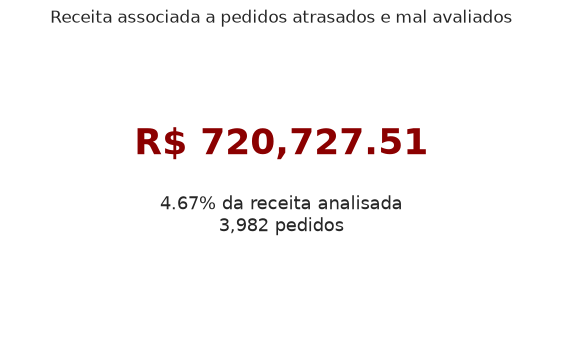

In [87]:
plt.figure(figsize=(7, 4))

plt.text(
    0.5,
    0.60,
    f'R$ {receita_em_risco:,.2f}',
    ha='center',
    fontsize=26,
    color='darkred',
    fontweight='bold'
)

plt.text(
    0.5,
    0.35,
    f'{percentual_receita_risco:.2f}% da receita analisada\n'
    f'{pedidos_em_risco:,} pedidos',
    ha='center',
    fontsize=13
)

plt.axis('off')
plt.title('Receita associada a pedidos atrasados e mal avaliados')

plt.show()

# Analise por estado


In [88]:
risco_estado = (
    df_pedidos.loc[filtro_risco]
    .groupby('customer_state', as_index=False)
    .agg(
        receita_em_risco=('payment_value', 'sum'),
        pedidos_em_risco=('order_id', 'nunique')
    )
)

receita_estado = (
    df_pedidos
    .groupby('customer_state', as_index=False)
    .agg(
        receita_total=('payment_value', 'sum'),
        pedidos_total=('order_id', 'nunique')
    )
)

comparativo_estado = receita_estado.merge(
    risco_estado,
    on='customer_state',
    how='left'
)

comparativo_estado[
    ['receita_em_risco', 'pedidos_em_risco']
] = comparativo_estado[
    ['receita_em_risco', 'pedidos_em_risco']
].fillna(0)

comparativo_estado['taxa_risco'] = (
    comparativo_estado['receita_em_risco'] /
    comparativo_estado['receita_total'] * 100
)

comparativo_estado.sort_values(
    'receita_em_risco',
    ascending=False
).head(10)

,customer_state,receita_total,pedidos_total,receita_em_risco,pedidos_em_risco,taxa_risco
25,SP,5769221.49,40495,178671.95,970.0,3.096985
18,RJ,2056101.21,12353,177932.98,1064.0,8.653902
10,MG,1819321.70,11355,52820.89,298.0,2.903329
4,BA,591270.60,3256,46939.07,231.0,7.938678
22,RS,861608.40,5344,34288.34,206.0,3.979574
5,CE,266463.97,1279,24294.00,119.0,9.117180
23,SC,595361.91,3547,23282.35,170.0,3.910621
15,PE,309074.59,1593,21666.54,105.0,7.010133
17,PR,781919.55,4923,20916.98,101.0,2.675081
9,MA,147807.29,717,19958.79,79.0,13.503251


Usaremos duas visões:

- risco absoluto: mostra onde está o maior valor financeiro;
- risco proporcional: mostra onde o problema é maior em relação à receita daquele estado.

Estados mais populosos podem ter risco absoluto alto apenas por concentrarem mais pedidos. Por isso, também é importante observar a taxa proporcional.

/tmp/ipykernel_51223/383835990.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_51223/383835990.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


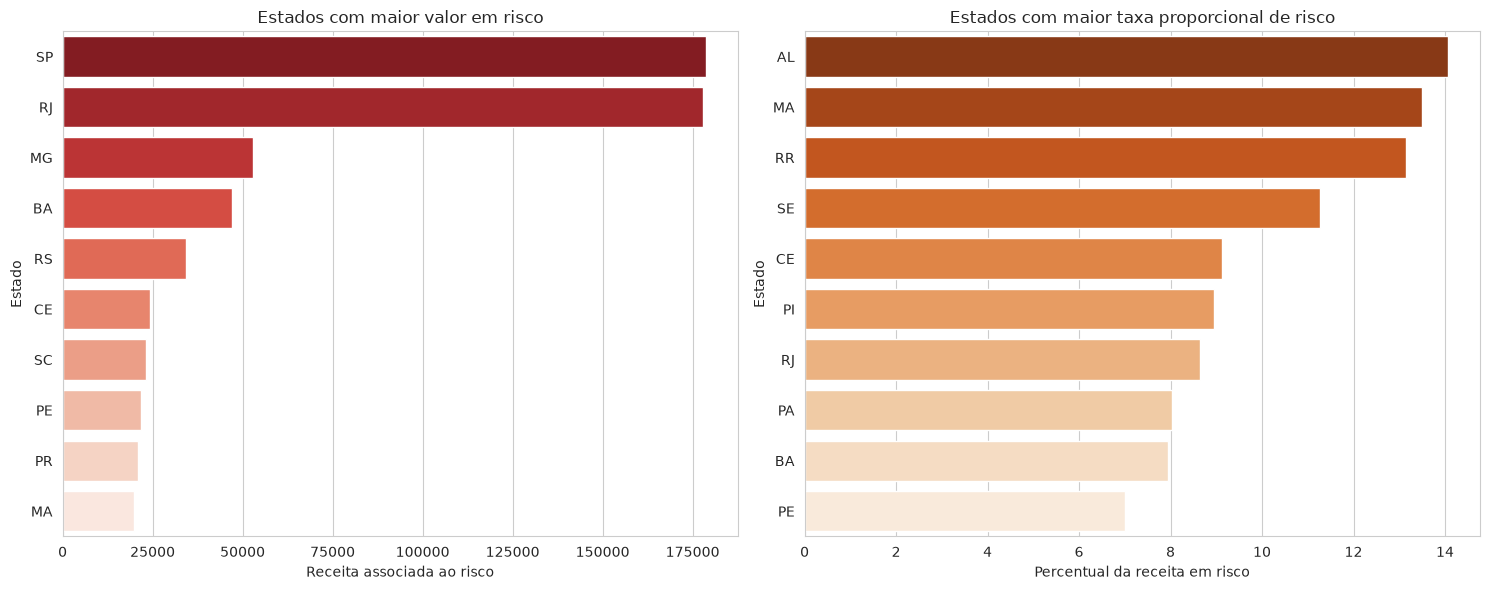

In [89]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

top_valor = comparativo_estado.sort_values(
    'receita_em_risco',
    ascending=False
).head(10)

sns.barplot(
    data=top_valor,
    x='receita_em_risco',
    y='customer_state',
    palette='Reds_r',
    ax=axes[0]
)

axes[0].set_title('Estados com maior valor em risco')
axes[0].set_xlabel('Receita associada ao risco')
axes[0].set_ylabel('Estado')

top_taxa = comparativo_estado.sort_values(
    'taxa_risco',
    ascending=False
).head(10)

sns.barplot(
    data=top_taxa,
    x='taxa_risco',
    y='customer_state',
    palette='Oranges_r',
    ax=axes[1]
)

axes[1].set_title('Estados com maior taxa proporcional de risco')
axes[1].set_xlabel('Percentual da receita em risco')
axes[1].set_ylabel('Estado')

plt.tight_layout()
plt.show()

Análise por categoria

In [90]:
df_itens = (
    items
    .merge(products, on='product_id', how='left')
    .merge(category_translation, on='product_category_name', how='left')
    .merge(
        orders_entregues[
            [
                'order_id',
                'foi_atraso',
                'dias_atraso'
            ]
        ],
        on='order_id',
        how='inner'
    )
    .merge(
        reviews_pedido[
            [
                'order_id',
                'review_score'
            ]
        ],
        on='order_id',
        how='left'
    )
)

df_itens['receita_item'] = (
    df_itens['price'].fillna(0) +
    df_itens['freight_value'].fillna(0)
)

df_itens.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,foi_atraso,dias_atraso,review_score,receita_item
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,cool_stuff,False,-9,5.0,72.19
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,pet_shop,False,-3,4.0,259.83
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,furniture_decor,False,-14,5.0,216.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0,perfumery,False,-6,4.0,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,garden_tools,False,-16,5.0,218.04


A análise por categoria será feita no nível do item.

Isso acontece porque um pedido pode possuir mais de um produto.

Para evitar repetir o valor total do pedido em cada item, usamos:

`price + freight_value`

Esse valor representa o valor comercial de cada item.

In [91]:
filtro_risco_itens = (
    (df_itens['foi_atraso'] == True) &
    (df_itens['review_score'] <= 2)
)

risco_categoria = (
    df_itens.loc[filtro_risco_itens]
    .groupby('product_category_name', as_index=False)
    .agg(
        receita_em_risco=('receita_item', 'sum'),
        pedidos_em_risco=('order_id', 'nunique'),
        itens_em_risco=('order_item_id', 'nunique')
    )
    .sort_values(
        'receita_em_risco',
        ascending=False
    )
)

risco_categoria.head(10)

,product_category_name,receita_em_risco,pedidos_em_risco,itens_em_risco
58,relogios_presentes,64858.98,247,3
10,beleza_saude,63279.12,385,21
12,cama_mesa_banho,60879.42,431,4
30,esporte_lazer,56202.67,316,3
7,automotivo,52139.19,166,4
48,moveis_decoracao,45486.22,269,6
39,informatica_acessorios,42602.31,251,6
8,bebes,31621.51,148,2
63,utilidades_domesticas,28831.75,186,6
24,cool_stuff,27877.70,130,2


/tmp/ipykernel_51223/2887651534.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


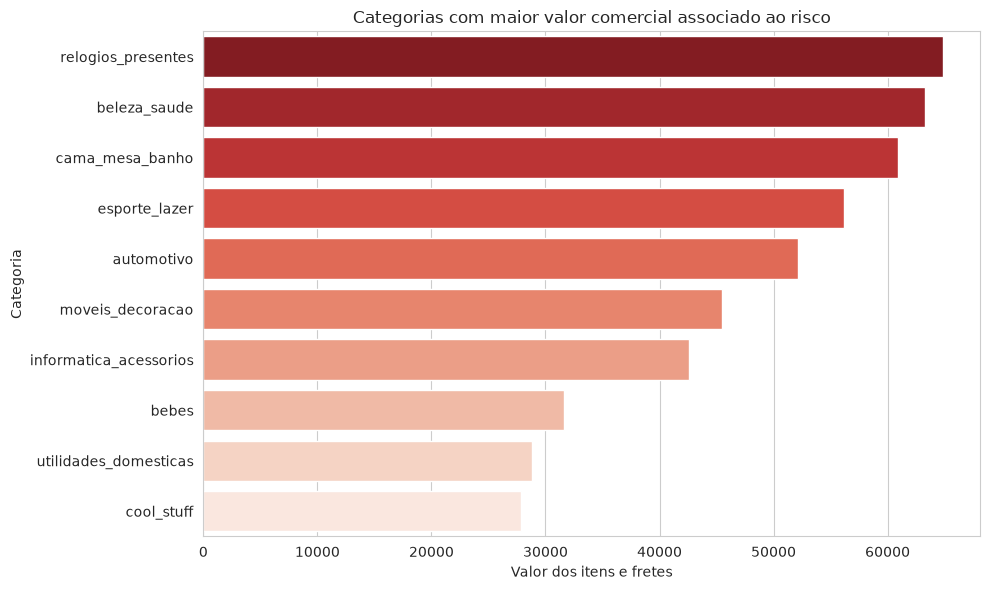

In [92]:
top_categorias = risco_categoria.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_categorias,
    x='receita_em_risco',
    y='product_category_name',
    palette='Reds_r'
)

plt.title('Categorias com maior valor comercial associado ao risco')
plt.xlabel('Valor dos itens e fretes')
plt.ylabel('Categoria')

plt.tight_layout()
plt.show()

# Análise do tempo de entrega

In [93]:
df_pedidos['tempo_ate_postagem'] = (
    df_pedidos['order_delivered_carrier_date'] -
    df_pedidos['order_approved_at']
).dt.days

df_pedidos['tempo_apos_postagem'] = (
    df_pedidos['order_delivered_customer_date'] -
    df_pedidos['order_delivered_carrier_date']
).dt.days

tempo_entrega = (
    df_pedidos
    .groupby('foi_atraso')
    .agg(
        mediana_ate_postagem=('tempo_ate_postagem', 'median'),
        media_ate_postagem=('tempo_ate_postagem', 'mean'),
        mediana_apos_postagem=('tempo_apos_postagem', 'median'),
        media_apos_postagem=('tempo_apos_postagem', 'mean')
    )
    .reset_index()
)

tempo_entrega

,foi_atraso,mediana_ate_postagem,media_ate_postagem,mediana_apos_postagem,media_apos_postagem
0,False,1.0,2.095689,6.0,7.533616
1,True,3.0,5.051729,26.0,27.388124


O tempo total foi dividido em duas partes:

- tempo até a postagem;
- tempo entre a postagem e a entrega ao cliente.

Essa separação ajuda a identificar em qual etapa existe maior demora.

Esse resultado não permite afirmar que a transportadora é a única causa do atraso. Ele apenas mostra qual etapa apresenta maior tempo médio ou mediano.

In [94]:
correlacao_frete = df_itens[
    ['freight_value', 'dias_atraso']
].corr().iloc[0, 1]

correlacao_peso = df_itens[
    ['product_weight_g', 'dias_atraso']
].corr().iloc[0, 1]

print(f'Correlação entre frete e atraso: {correlacao_frete:.2f}')
print(f'Correlação entre peso e atraso: {correlacao_peso:.2f}')

Correlação entre frete e atraso: -0.04
Correlação entre peso e atraso: 0.01


Uma correlação próxima de zero indica que não foi identificada uma relação linear forte entre as variáveis analisadas.

Isso não prova que o frete ou o peso não influenciam o atraso. Também não prova que a malha logística seja a causa do problema.

Para identificar causas com maior segurança, seriam necessários outros dados, como transportadora, rota, distância e capacidade operacional.

# Análise temporal

In [95]:
df_pedidos['mes_compra'] = (
    df_pedidos['order_purchase_timestamp']
    .dt.to_period('M')
    .astype(str)
)

risco_mensal = (
    df_pedidos.loc[filtro_risco]
    .groupby('mes_compra', as_index=False)
    .agg(
        receita_em_risco=('payment_value', 'sum'),
        pedidos_em_risco=('order_id', 'nunique')
    )
)

risco_mensal.head()

,mes_compra,receita_em_risco,pedidos_em_risco
0,2016-09,0.00,1
1,2016-10,82.69,1
2,2017-01,2924.76,15
3,2017-02,4711.02,29
4,2017-03,10464.75,66


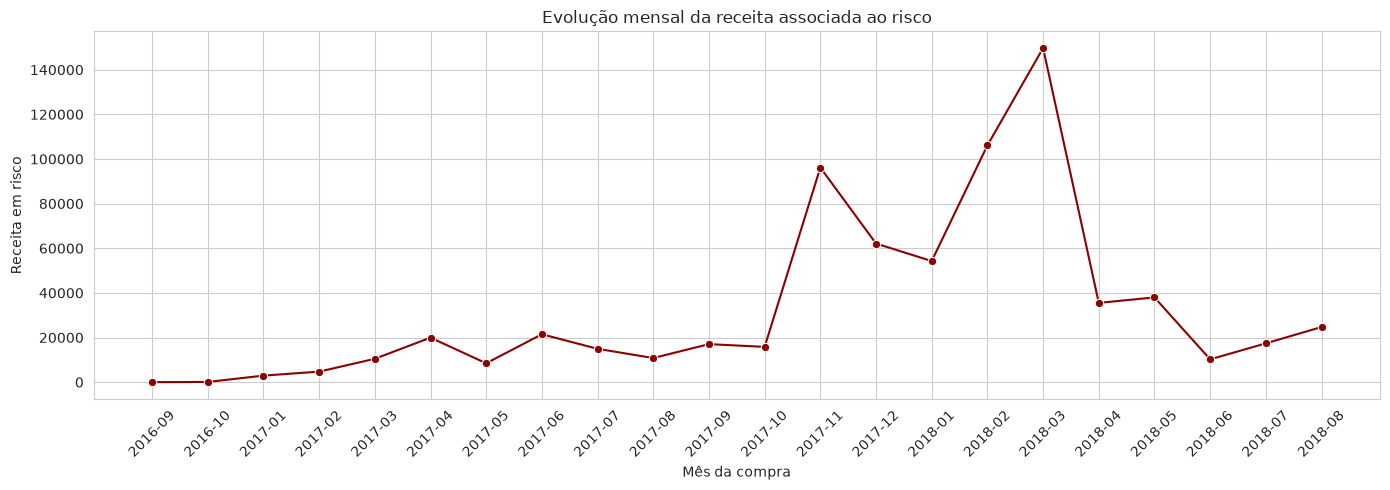

In [96]:
plt.figure(figsize=(14, 5))

sns.lineplot(
    data=risco_mensal,
    x='mes_compra',
    y='receita_em_risco',
    marker='o',
    color='darkred'
)

plt.title('Evolução mensal da receita associada ao risco')
plt.xlabel('Mês da compra')
plt.ylabel('Receita em risco')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

O gráfico mostra como o risco variou ao longo do tempo.

Não devemos afirmar automaticamente que o aumento ocorreu por causa da Black Friday.

A análise indica apenas que determinados meses apresentaram maior valor associado ao risco. Para confirmar a influência da Black Friday, seria necessário comparar esses meses com outros períodos e analisar o volume total de pedidos.

# Perfil dos clientes


In [97]:
compras_cliente = (
    df_pedidos
    .groupby('customer_unique_id')
    ['order_id']
    .nunique()
    .reset_index(name='total_pedidos_cliente')
)

df_pedidos = df_pedidos.merge(
    compras_cliente,
    on='customer_unique_id',
    how='left'
)

df_pedidos['perfil_cliente'] = np.where(
    df_pedidos['total_pedidos_cliente'] > 1,
    'Cliente recorrente',
    'Cliente com uma compra'
)

df_pedidos[['customer_unique_id', 'perfil_cliente']].head()

,customer_unique_id,perfil_cliente
0,7c396fd4830fd04220f754e42b4e5bff,Cliente recorrente
1,af07308b275d755c9edb36a90c618231,Cliente com uma compra
2,3a653a41f6f9fc3d2a113cf8398680e8,Cliente com uma compra
3,7c142cf63193a1473d2e66489a9ae977,Cliente com uma compra
4,72632f0f9dd73dfee390c9b22eb56dd6,Cliente com uma compra


In [67]:
risco_perfil = (
    df_pedidos.loc[filtro_risco]
    .groupby('perfil_cliente', as_index=False)
    .agg(
        receita_em_risco=('payment_value', 'sum'),
        pedidos_em_risco=('order_id', 'nunique')
    )
)

risco_perfil

,perfil_cliente,receita_em_risco,pedidos_em_risco
0,Cliente com uma compra,694723.84,3796
1,Cliente recorrente,26003.67,186


/tmp/ipykernel_51223/3684496472.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  grafico_perfil = sns.barplot(


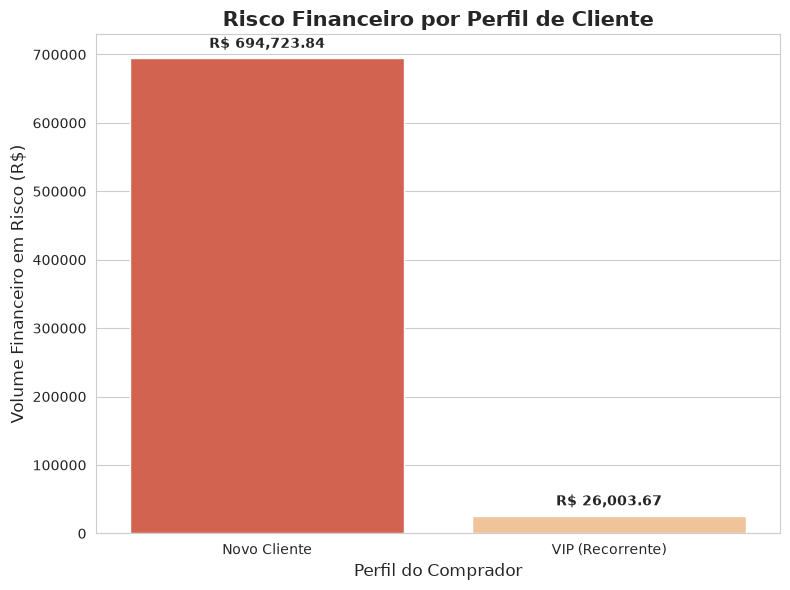

In [100]:
# 1. Garantindo a frequência de compra sem sobrescrever df_pedidos
if 'total_pedidos_cliente' in df_pedidos.columns:
    df_perfil = df_pedidos.copy()
    coluna_freq = 'total_pedidos_cliente'
else:
    freq_cliente = (
        df_pedidos.groupby('customer_unique_id')['order_id']
        .nunique()
        .reset_index(name='total_pedidos')
    )
    df_perfil = df_pedidos.merge(freq_cliente, on='customer_unique_id', how='left')
    coluna_freq = 'total_pedidos'

# 2. Classificando o perfil do cliente
df_perfil['perfil_cliente'] = np.where(
    df_perfil[coluna_freq] > 1, 'VIP (Recorrente)', 'Novo Cliente'
)

# 3. Filtrando pedidos em risco (atraso + nota baixa) e somando por perfil
filtro_risco = (df_perfil['foi_atraso'] == True) & (df_perfil['review_score'] <= 2)

risco_perfil = (
    df_perfil.loc[filtro_risco]
    .groupby('perfil_cliente', as_index=False)['payment_value']
    .sum()
)

# 4. Construindo o gráfico
plt.figure(figsize=(8, 6))
grafico_perfil = sns.barplot(
    data=risco_perfil,
    x='perfil_cliente',
    y='payment_value',
    palette='OrRd_r'
)

plt.title('Risco Financeiro por Perfil de Cliente', fontsize=15, fontweight='bold')
plt.ylabel('Volume Financeiro em Risco (R$)', fontsize=12)
plt.xlabel('Perfil do Comprador', fontsize=12)

# 5. Adicionando rótulos de valor em cada barra
for p in grafico_perfil.patches:
    grafico_perfil.annotate(
        f'R$ {p.get_height():,.2f}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom',
        xytext=(0, 5), textcoords='offset points',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

Essa análise mostra o perfil dos clientes que possuem pedidos associados ao risco.

Ela não comprova que o atraso causou a perda de recompra.

Para medir retenção de forma correta, seria necessário comparar compras posteriores ao pedido atrasado dentro de uma janela de tempo.

In [68]:
pedidos_nota_5 = df_pedidos[
    df_pedidos['review_score'] == 5
]['dias_atraso']

print(f'Média dos pedidos com nota 5: {pedidos_nota_5.mean():.2f} dias')
print(f'Mediana dos pedidos com nota 5: {pedidos_nota_5.median():.2f} dias')

Média dos pedidos com nota 5: -13.38 dias
Mediana dos pedidos com nota 5: -13.00 dias


A mediana é utilizada como referência principal porque é menos influenciada por casos extremos.

Esse resultado não deve ser apresentado como uma meta definitiva. Ele representa apenas o comportamento dos pedidos que receberam nota 5 na base histórica.

# Simulação financeira

In [70]:
risco_rj = comparativo_estado.loc[
    comparativo_estado['customer_state'] == 'RJ',
    'receita_em_risco'
].sum()

recuperacao_hipotetica = risco_rj * 0.20

print(f'Receita associada ao risco no RJ: R$ {risco_rj:,.2f}')
print(
    f'Cenário hipotético de recuperação de 20%: '
    f'R$ {recuperacao_hipotetica:,.2f}'
)

Receita associada ao risco no RJ: R$ 177,932.98
Cenário hipotético de recuperação de 20%: R$ 35,586.60


/tmp/ipykernel_51223/3093320565.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  grafico_sim = sns.barplot(


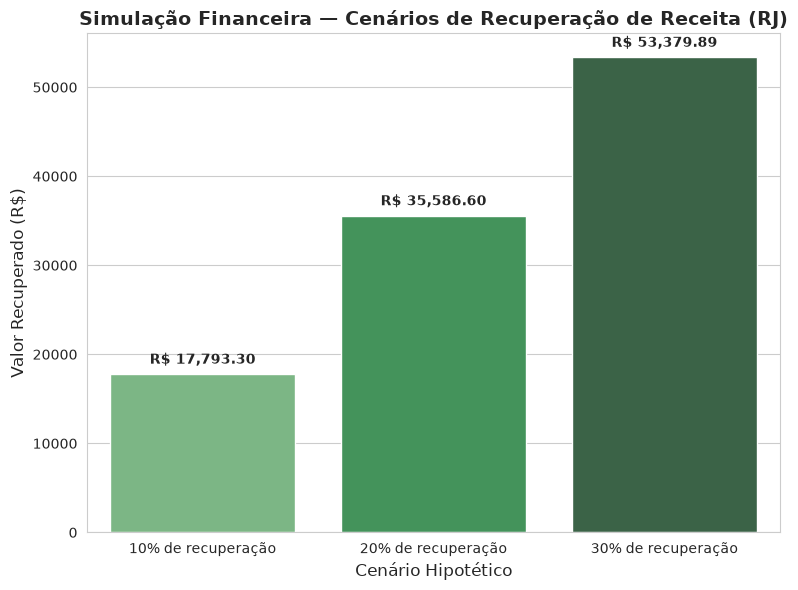

Aviso metodológico: os valores acima representam um cenário hipotético de recuperação de receita, não um cálculo de ROI, pois não há dados de custo de intervenção logística no dataset.


In [101]:
# 1. Calculando o total de receita em risco por estado (base já consolidada)
risco_por_estado = (
    df_pedidos.loc[filtro_risco]
    .groupby('customer_state', as_index=False)['payment_value']
    .sum()
    .rename(columns={'payment_value': 'receita_em_risco'})
)

# 2. Simulando diferentes cenários de recuperação (10%, 20%, 30%)
cenarios = [0.10, 0.20, 0.30]
risco_rj = risco_por_estado.loc[
    risco_por_estado['customer_state'] == 'RJ', 'receita_em_risco'
].values[0]

simulacao = pd.DataFrame({
    'cenario': [f'{int(c*100)}% de recuperação' for c in cenarios],
    'valor_recuperado': [risco_rj * c for c in cenarios]
})

# 3. Construindo o gráfico
plt.figure(figsize=(8, 6))
grafico_sim = sns.barplot(
    data=simulacao,
    x='cenario',
    y='valor_recuperado',
    palette='Greens_d'
)

plt.title('Simulação Financeira — Cenários de Recuperação de Receita (RJ)',
          fontsize=14, fontweight='bold')
plt.ylabel('Valor Recuperado (R$)', fontsize=12)
plt.xlabel('Cenário Hipotético', fontsize=12)

for p in grafico_sim.patches:
    grafico_sim.annotate(
        f'R$ {p.get_height():,.2f}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom',
        xytext=(0, 5), textcoords='offset points',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

print("Aviso metodológico: os valores acima representam um cenário hipotético "
      "de recuperação de receita, não um cálculo de ROI, pois não há dados "
      "de custo de intervenção logística no dataset.")

Esse valor é apenas um cenário hipotético.

Ele não é ROI, pois não temos:

- custo da intervenção;
- investimento necessário;
- prazo para implantação;
- margem de lucro;
- garantia de recuperação.

Por isso, o termo correto é “potencial de recuperação de receita”.

# Conclusão

A análise indica que os pedidos atrasados estão associados a avaliações mais baixas e a um volume financeiro relevante de pedidos com experiência negativa.

A base foi organizada com uma linha por pedido para evitar duplicação de pagamentos, avaliações e receita. As categorias foram analisadas separadamente no nível dos itens.

Os resultados devem ser interpretados como associações observadas na base histórica. Eles não comprovam, sozinhos, que o atraso causou a perda de recompra ou que uma única etapa logística seja responsável pelo problema.

## Recomendações

1. Monitorar a taxa de atraso por estado e por mês.
2. Acompanhar a mediana e o P90 do prazo de entrega.
3. Investigar os estados com maior taxa proporcional de risco.
4. Separar o tempo até a postagem do tempo após a postagem.
5. Avaliar rotas e transportadoras com dados adicionais.
6. Priorizar clientes em sua primeira compra.
7. Criar uma análise de recompra por período após a entrega.
8. Acompanhar o valor de pedidos atrasados com avaliações baixas.
9. Não utilizar “ROI” sem estimar os custos da intervenção.
10. Atualizar todos os números do relatório após a execução deste notebook.

## Limitações

- Pedidos sem data de entrega foram retirados da análise principal.
- A base é histórica e não representa necessariamente o cenário atual.
- Correlação não representa causalidade.
- A recompra ainda não foi calculada em uma janela temporal posterior ao atraso.
- Não há informação completa sobre custos de transportadora e rotas.
- A receita em risco representa valor associado a uma experiência negativa, não perda financeira comprovada.